# Naiwny Bayes — przewidywanie subskrypcji

**Cel:** zbudować klasyfikator przewidujący czy osoba zostanie subskrybentem usługi na podstawie 4 cech demograficznych.

**Dataset:** `subscribers.xlsx` (1024 próbek, 4 cechy kategoryczne, target binarny)

**Cechy:**
- `Age` — grupa wiekowa: senior, young adult, gen. X, adult
- `Sex` — płeć: M, F
- `Income` — dochód: low, average, high
- `Residence` — miejsce zamieszkania: country, suburb, city

**Target:** `Subscribes` (0 = nie subskrybuje, 1 = subskrybuje)

**Plan notebooka:**
1. Wczytanie i eksploracja danych
2. Implementacja Naiwnego Bayesa od zera (klasa w `utils/models.py`)
3. Trenowanie i ewaluacja
4. Porównanie z drzewem decyzyjnym
5. Wnioski

## 1. Setup — importy i konfiguracja

Importujemy biblioteki i włączamy `autoreload`, żeby zmiany w plikach `.py` z `utils/` były automatycznie podchwytywane przez notebook (bez restartu kernela).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

# Reprodukowalność wyników (random_state = 42 w całym notebooku)
np.random.seed(42)

# Konfiguracja wyświetlania
pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 100

print("Setup OK")

Setup OK


## 2. Wczytanie danych

Plik `subscribers.xlsx` ma puste wiersze na początku przed nagłówkami. Zamiast hardcodować `skiprows`, automatycznie wykrywamy wiersz z nagłówkami (ten zawierający `Age`) — kod jest odporny na ewentualne zmiany w pliku.

In [2]:
# Wczytaj plik bez interpretacji nagłówków
df_raw = pd.read_excel('../data/subscribers.xlsx', header=None)

# Znajdź wiersz zawierający nagłówek 'Age'
header_row = df_raw[df_raw.apply(lambda row: 'Age' in row.values, axis=1)].index[0]

# Wczytaj ponownie z prawidłowym nagłówkiem
df = pd.read_excel(
    '../data/subscribers.xlsx',
    skiprows=header_row + 1,
    header=None,
    names=['Age', 'Sex', 'Income', 'Residence', 'Subscribes']
)

# Czyszczenie
df = df.dropna(how='all').reset_index(drop=True)
df['Subscribes'] = df['Subscribes'].astype(int)

print(f"Kształt: {df.shape}")
print(f"Kolumny: {df.columns.tolist()}")
df.head(10)

Kształt: (1024, 5)
Kolumny: ['Age', 'Sex', 'Income', 'Residence', 'Subscribes']


,Age,Sex,Income,Residence,Subscribes
0,senior,M,low,country,1
1,young adult,M,low,suburb,0
2,gen. X,F,low,suburb,0
3,young adult,F,low,suburb,0
4,gen. X,M,high,city,1
5,gen. X,M,low,city,1
6,young adult,F,low,country,0
7,young adult,F,low,city,1
8,gen. X,F,low,city,0
9,young adult,F,average,city,1


## 3. Eksploracja danych

Sprawdzamy:
- **Typy kolumn** — czy pandas poprawnie rozpoznał typy danych
- **Braki danych** — czy potrzebny preprocessing
- **Unikalne wartości** — pełna lista kategorii w każdej cesze
- **Balans klas** — czy klasy są zbalansowane (wpływa na metodę ewaluacji)

In [3]:
print("── Typy kolumn ──")
print(df.dtypes)

print("\n── Braki danych ──")
print(df.isnull().sum())

print("\n── Unikalne wartości w każdej kolumnie ──")
for col in df.columns:
    unique_vals = df[col].unique()
    print(f"  {col}: {unique_vals}")

print("\n── Rozkład klasy docelowej (Subscribes) ──")
counts = df['Subscribes'].value_counts()
print(counts)
print(f"\nBalans: {(counts / len(df) * 100).round(1).to_dict()} %")

── Typy kolumn ──
Age             str
Sex             str
Income          str
Residence       str
Subscribes    int64
dtype: object

── Braki danych ──
Age           0
Sex           0
Income        0
Residence     0
Subscribes    0
dtype: int64

── Unikalne wartości w każdej kolumnie ──
  Age: <StringArray>
['senior', 'young adult', 'gen. X', 'adult']
Length: 4, dtype: str
  Sex: <StringArray>
['M', 'F']
Length: 2, dtype: str
  Income: <StringArray>
['low', 'high', 'average']
Length: 3, dtype: str
  Residence: <StringArray>
['country', 'suburb', 'city']
Length: 3, dtype: str
  Subscribes: [1 0]

── Rozkład klasy docelowej (Subscribes) ──
Subscribes
0    660
1    364
Name: count, dtype: int64

Balans: {0: 64.5, 1: 35.5} %


## 4. Wizualizacja rozkładu cech

Dla każdej cechy generujemy wykres słupkowy pokazujący jak wartości tej cechy rozkładają się między klasami docelowymi. To pomaga zidentyfikować **cechy dyskryminujące** — takie, dla których rozkład wyraźnie różni się między klasami (np. czy `Income=high` częściej koreluje z `Subscribes=1`).

Wykres zapisywany jest do `plots/` — wykorzystamy go w sprawozdaniu.

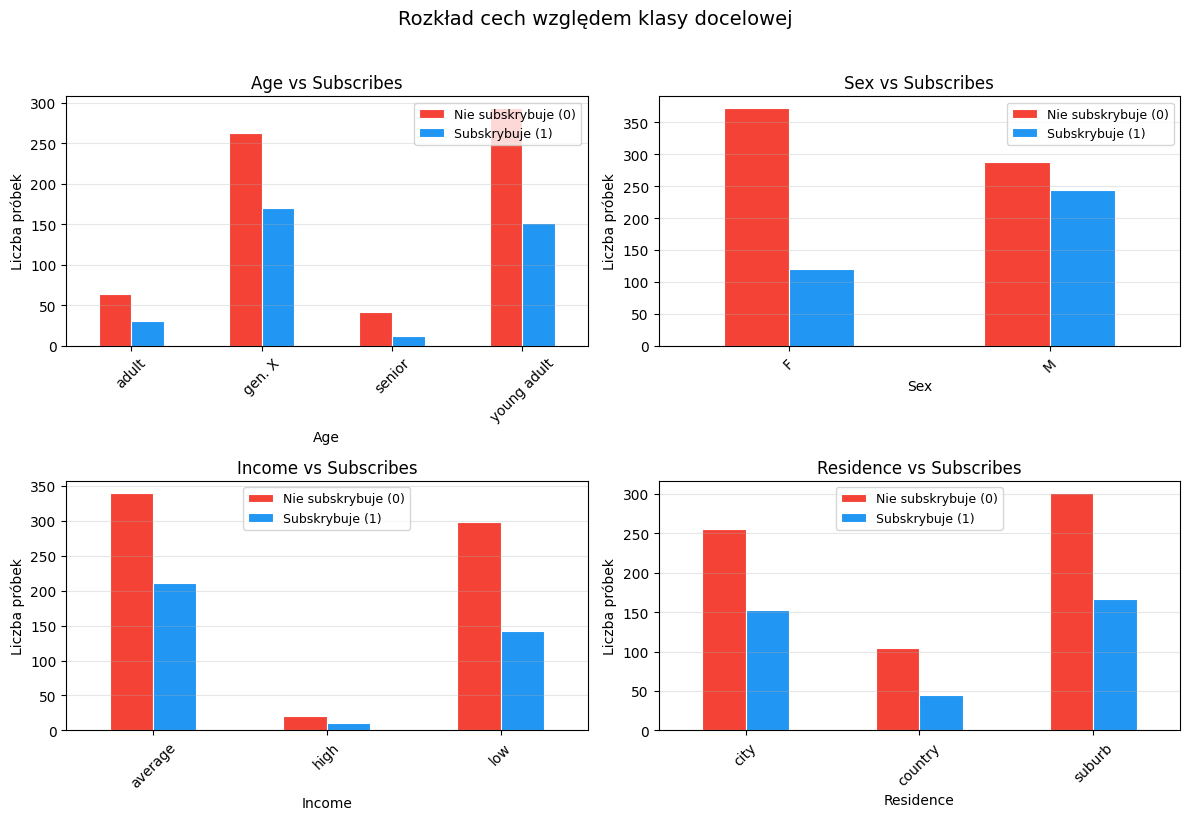

✓ Wykres zapisany do plots/bayes_features_distribution.png


In [4]:
features = ['Age', 'Sex', 'Income', 'Residence']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    crosstab = pd.crosstab(df[feature], df['Subscribes'])
    crosstab.plot(kind='bar', ax=axes[i], color=['#F44336', '#2196F3'],
                   edgecolor='white', linewidth=0.8)
    axes[i].set_title(f'{feature} vs Subscribes', fontsize=12)
    axes[i].set_ylabel('Liczba próbek')
    axes[i].set_xlabel(feature)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(['Nie subskrybuje (0)', 'Subskrybuje (1)'], fontsize=9)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Rozkład cech względem klasy docelowej', fontsize=14, y=1.02)
plt.tight_layout()

os.makedirs('../plots', exist_ok=True)
plt.savefig('../plots/bayes_features_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Wykres zapisany do plots/bayes_features_distribution.png")

## 5. Podział na zbiór treningowy i testowy

Dzielimy dane 80/20 ze **stratyfikacją** — proporcje klas zostają zachowane w obu zbiorach. Dla niezbalansowanych danych (jak nasz — 64.5% / 35.5%) to kluczowe, żeby uniknąć sytuacji w której zbiór testowy ma inny rozkład klas niż treningowy.

`random_state=42` zapewnia reprodukowalność — każdy z grupy dostanie ten sam podział.

In [5]:
from sklearn.model_selection import train_test_split

X = df[['Age', 'Sex', 'Income', 'Residence']].copy()
y = df['Subscribes'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} próbek")
print(f"Test:  {len(X_test)} próbek")
print(f"\nBalans w train: {np.bincount(y_train) / len(y_train)}")
print(f"Balans w test:  {np.bincount(y_test) / len(y_test)}")

Train: 819 próbek
Test:  205 próbek

Balans w train: [0.64468864 0.35531136]
Balans w test:  [0.64390244 0.35609756]


## 6. Trenowanie Naiwnego Bayesa

Używamy klasy `CategoricalNaiveBayes` zaimplementowanej od zera w pliku `utils/models.py`. Klasa implementuje:
- **Prior** P(c) — częstość występowania każdej klasy w treningu
- **Likelihood** P(cecha=v | c) z **wygładzaniem Laplace'a** (α=1) — żeby uniknąć zerowych prawdopodobieństw
- **Predykcja** w przestrzeni logarytmów (stabilność numeryczna)

**Wzór:**
$$P(c | x) \propto P(c) \cdot \prod_{i} P(x_i | c)$$

In [6]:
from utils.models import CategoricalNaiveBayes

model = CategoricalNaiveBayes(alpha=1.0)
model.fit(X_train, y_train)

train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print(f"Accuracy na zbiorze treningowym: {train_acc:.4f}")
print(f"Accuracy na zbiorze testowym:    {test_acc:.4f}")

Accuracy na zbiorze treningowym: 0.6593
Accuracy na zbiorze testowym:    0.6439


## 7. Analiza wyuczonego modelu

Wypisujemy:
- **Priory** — częstości klas (powinny odpowiadać balansowi danych)
- **Likelihoods dla klasy 1** — które wartości cech najsilniej kojarzą się z subskrypcją
- **Przykładowe predykcje** — pierwsze 10 próbek testowych z prawdopodobieństwami

In [8]:
print("── Wyuczone priory ──")
for c, p in model.priors.items():
    print(f"  P(Subscribes={c}) = {p:.4f}")

print("\n── Likelihoods dla klasy 1 (subskrybenci) ──")
for feature in ['Age', 'Sex', 'Income', 'Residence']:
    print(f"\n  P({feature} = v | Subscribes=1):")
    for value, prob in model.likelihoods[1][feature].items():
        print(f"    {value}: {prob:.4f}")

print("\n── Przykładowe predykcje na zbiorze testowym ──")
test_sample = X_test.head(10).copy()
test_sample['rzeczywista'] = y_test[:10]
test_sample['predykcja'] = model.predict(X_test.head(10))
probas = model.predict_proba(X_test.head(10))
test_sample['P(0)'] = probas[:, 0].round(3)
test_sample['P(1)'] = probas[:, 1].round(3)
print(test_sample)

── Wyuczone priory ──
  P(Subscribes=0) = 0.6447
  P(Subscribes=1) = 0.3553

── Likelihoods dla klasy 1 (subskrybenci) ──

  P(Age = v | Subscribes=1):
    young adult: 0.4000
    senior: 0.0339
    gen. X: 0.4780
    adult: 0.0881

  P(Sex = v | Subscribes=1):
    M: 0.6792
    F: 0.3208

  P(Income = v | Subscribes=1):
    average: 0.5816
    low: 0.3878
    high: 0.0306

  P(Residence = v | Subscribes=1):
    city: 0.4082
    suburb: 0.4660
    country: 0.1259

── Przykładowe predykcje na zbiorze testowym ──
             Age Sex   Income Residence  rzeczywista  predykcja   P(0)   P(1)
593  young adult   F      low      city            0          0  0.784  0.216
152        adult   F      low    suburb            0          0  0.795  0.205
137        adult   F  average    suburb            0          0  0.753  0.247
108  young adult   M  average    suburb            1          0  0.543  0.457
209        adult   F  average    suburb            1          0  0.753  0.247
338  young adul

## 8. Macierz konfuzji i pełny raport klasyfikacji

Sama accuracy nie wystarcza dla niezbalansowanych danych. Sprawdzamy **macierz konfuzji** żeby zobaczyć dokładnie gdzie model się myli:
- **TN** (lewy górny) — poprawnie odrzuceni
- **FP** (prawy górny) — błędnie zaklasyfikowani jako subskrybenci
- **FN** (lewy dolny) — przegapieni subskrybenci  
- **TP** (prawy dolny) — poprawnie wykryci subskrybenci

Dodatkowo **precision/recall/F1**:
- **Precision** — z tych których model wskazał jako subskrybentów, ilu naprawdę nimi jest
- **Recall** — z prawdziwych subskrybentów, ilu model wykrył
- **F1** — średnia harmoniczna precision i recall

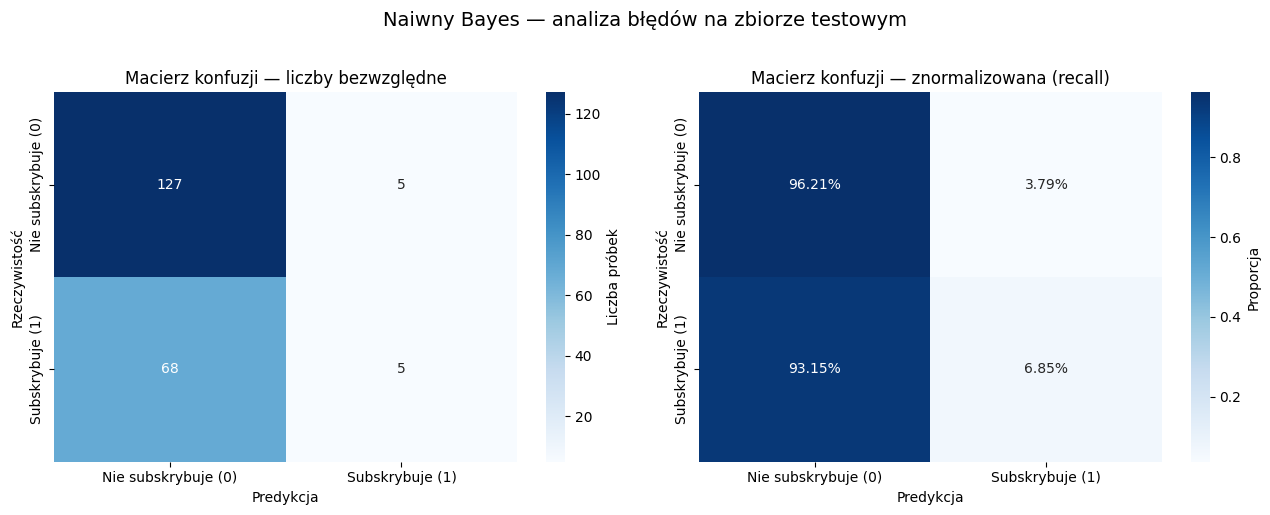


── Raport klasyfikacji ──
                 precision    recall  f1-score   support

Nie subskrybuje     0.6513    0.9621    0.7768       132
    Subskrybuje     0.5000    0.0685    0.1205        73

       accuracy                         0.6439       205
      macro avg     0.5756    0.5153    0.4486       205
   weighted avg     0.5974    0.6439    0.5431       205



In [9]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred_nb = model.predict(X_test)

# ── Macierz konfuzji ──
cm = confusion_matrix(y_test, y_pred_nb)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Lewa: liczby bezwzględne
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Nie subskrybuje (0)', 'Subskrybuje (1)'],
            yticklabels=['Nie subskrybuje (0)', 'Subskrybuje (1)'],
            cbar_kws={'label': 'Liczba próbek'})
axes[0].set_xlabel('Predykcja')
axes[0].set_ylabel('Rzeczywistość')
axes[0].set_title('Macierz konfuzji — liczby bezwzględne')

# Prawa: znormalizowana (po wierszach = recall każdej klasy)
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Nie subskrybuje (0)', 'Subskrybuje (1)'],
            yticklabels=['Nie subskrybuje (0)', 'Subskrybuje (1)'],
            cbar_kws={'label': 'Proporcja'})
axes[1].set_xlabel('Predykcja')
axes[1].set_ylabel('Rzeczywistość')
axes[1].set_title('Macierz konfuzji — znormalizowana (recall)')

plt.suptitle('Naiwny Bayes — analiza błędów na zbiorze testowym', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../plots/bayes_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Raport klasyfikacji ──
print("\n── Raport klasyfikacji ──")
print(classification_report(y_test, y_pred_nb, 
                             target_names=['Nie subskrybuje', 'Subskrybuje'],
                             digits=4))

## 9. Drzewo decyzyjne — porównanie

Implementujemy drzewo decyzyjne od zera (klasa `DecisionTreeCategorical` w `utils/models.py`) i trenujemy je na tych samych danych. Drzewa są **nieliniowe** — mogą wykrywać interakcje między cechami (np. "jeśli `Age=senior` ORAZ `Income=high` to subskrybuje"), czego Naiwny Bayes z założenia nie potrafi.

Sprawdzamy czy bardziej elastyczny model poradzi sobie lepiej z tym datasetem.

In [12]:
from utils.models import DecisionTreeCategorical

# Trenowanie drzewa
tree = DecisionTreeCategorical(max_depth=6, min_samples_split=5)
tree.fit(X_train, y_train)

train_acc_tree = tree.score(X_train, y_train)
test_acc_tree = tree.score(X_test, y_test)

print(f"Drzewo decyzyjne — Accuracy treningowy: {train_acc_tree:.4f}")
print(f"Drzewo decyzyjne — Accuracy testowy:    {test_acc_tree:.4f}")

print("\n── Struktura wyuczonego drzewa ──")
tree.print_tree()

Drzewo decyzyjne — Accuracy treningowy: 0.6789
Drzewo decyzyjne — Accuracy testowy:    0.6195

── Struktura wyuczonego drzewa ──
[Sex?]  (fallback: 0)
  = M:
    [Age?]  (fallback: 0)
      = young adult:
        [Residence?]  (fallback: 0)
          = city:
            [Income?]  (fallback: 0)
              = average:
                → Predykcja: 0
              = low:
                → Predykcja: 0
          = suburb:
            [Income?]  (fallback: 1)
              = low:
                → Predykcja: 1
              = average:
                → Predykcja: 1
              = high:
                → Predykcja: 0
          = country:
            [Income?]  (fallback: 0)
              = low:
                → Predykcja: 1
              = average:
                → Predykcja: 0
              = high:
                → Predykcja: 1
      = gen. X:
        [Income?]  (fallback: 0)
          = low:
            [Residence?]  (fallback: 0)
              = city:
                → Predykcja: 0


## 10. Porównanie modeli

Zestawiamy wyniki Naiwnego Bayesa i drzewa decyzyjnego na zbiorze testowym. Wykres słupkowy + macierz konfuzji drzewa pozwoli ocenić, który model lepiej radzi sobie z klasą mniejszościową (subskrybenci).

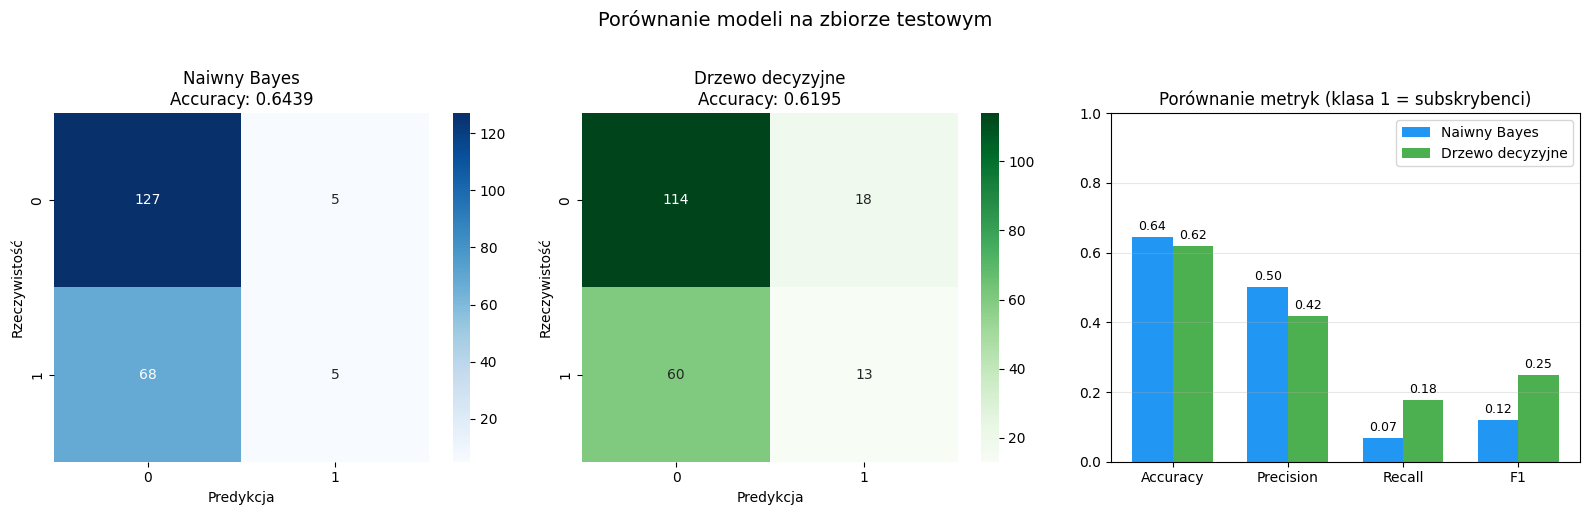


── Tabela porównawcza ──
           Naiwny Bayes  Drzewo decyzyjne
Accuracy         0.6439            0.6195
Precision        0.5000            0.4194
Recall           0.0685            0.1781
F1               0.1205            0.2500


In [13]:
y_pred_tree = tree.predict(X_test)
cm_tree = confusion_matrix(y_test, y_pred_tree)

# ── Wykres porównawczy ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Macierz konfuzji NB
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['0', '1'], yticklabels=['0', '1'])
axes[0].set_title(f'Naiwny Bayes\nAccuracy: {test_acc:.4f}')
axes[0].set_xlabel('Predykcja')
axes[0].set_ylabel('Rzeczywistość')

# Macierz konfuzji drzewa
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['0', '1'], yticklabels=['0', '1'])
axes[1].set_title(f'Drzewo decyzyjne\nAccuracy: {test_acc_tree:.4f}')
axes[1].set_xlabel('Predykcja')
axes[1].set_ylabel('Rzeczywistość')

# Porównanie metryk
from sklearn.metrics import precision_score, recall_score, f1_score

metrics_nb = {
    'Accuracy': test_acc,
    'Precision': precision_score(y_test, y_pred_nb),
    'Recall': recall_score(y_test, y_pred_nb),
    'F1': f1_score(y_test, y_pred_nb)
}
metrics_tree = {
    'Accuracy': test_acc_tree,
    'Precision': precision_score(y_test, y_pred_tree),
    'Recall': recall_score(y_test, y_pred_tree),
    'F1': f1_score(y_test, y_pred_tree)
}

x = np.arange(len(metrics_nb))
width = 0.35
axes[2].bar(x - width/2, metrics_nb.values(), width, label='Naiwny Bayes', color='#2196F3')
axes[2].bar(x + width/2, metrics_tree.values(), width, label='Drzewo decyzyjne', color='#4CAF50')
axes[2].set_xticks(x)
axes[2].set_xticklabels(metrics_nb.keys())
axes[2].set_ylim(0, 1)
axes[2].set_title('Porównanie metryk (klasa 1 = subskrybenci)')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

for i, (k, v) in enumerate(metrics_nb.items()):
    axes[2].text(i - width/2, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)
for i, (k, v) in enumerate(metrics_tree.items()):
    axes[2].text(i + width/2, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)

plt.suptitle('Porównanie modeli na zbiorze testowym', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../plots/bayes_vs_tree_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tabela porównawcza ──
comparison = pd.DataFrame({
    'Naiwny Bayes': metrics_nb,
    'Drzewo decyzyjne': metrics_tree
}).round(4)
print("\n── Tabela porównawcza ──")
print(comparison)

## 11. Wnioski

### Wyniki

| Metryka | Naiwny Bayes | Drzewo decyzyjne |
|---------|-------------|-----------------|
| Accuracy (test) | 0.6439 | 0.6195 |
| Precision (kl. 1) | 0.5000 | 0.4194 |
| Recall (kl. 1) | 0.0685 | 0.1781 |
| F1 (kl. 1) | 0.1205 | 0.2500 |
| Accuracy (train) | 0.6593 | 0.6789 |

### Naiwny Bayes
Osiągnął accuracy 64.4%, jednak analiza macierzy konfuzji ujawnia że model
niemal całkowicie ignoruje klasę mniejszościową (subskrybenci) — Recall=0.0685
oznacza wykrycie jedynie 5 z 73 prawdziwych subskrybentów. Wynika to z dwóch
przyczyn: niezbalansowania klas (64.5%/35.5%) oraz słabej siły dyskryminującej
dostępnych cech demograficznych. Accuracy modelu odpowiada dokładnie proporcji
klasy większościowej — jest to typowy znak "trivial classifier" (model który
zawsze przewiduje klasę 0).

### Drzewo decyzyjne
Uzyskało niższe accuracy (61.9%), ale znacznie wyższy F1=0.2500 dla klasy
subskrybentów dzięki zdolności do modelowania interakcji między cechami
(np. kombinacja Sex=M, Age=gen.X, Residence=suburb). Widoczny jest niewielki
overfitting (train: 67.9% vs test: 61.9%), co świadczy o dopasowaniu do
szumu w danych treningowych.

### Wnioski ogólne
Oba modele osiągają podobne, niskie wyniki — co wskazuje że 4 cechy
demograficzne (wiek, płeć, dochód, zamieszkanie) są niewystarczające do
wiarygodnego przewidywania subskrypcji. W zastosowaniu praktycznym należałoby
wzbogacić dataset o dodatkowe cechy behawioralne (np. historia zakupów,
aktywność online). Drzewo decyzyjne jest lepszym wyborem dla tego problemu
ze względu na wyższy F1 — w zastosowaniach gdzie koszt przeoczenia
subskrybenta jest wysoki, Recall jest ważniejszy od Accuracy.